In [1]:
import torch
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 定義圖片轉換為 tensor 的處理方式
transform = transforms.Compose([transforms.ToTensor()])

# 下載訓練和測試資料
trainset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

In [3]:
# 將訓練資料分割為訓練集（50,000筆）和驗證集（10,000筆）
train_size = 50000
val_size = 10000
train_dataset, val_dataset = torch.utils.data.random_split(trainset, [train_size, val_size])

# # 使用 DataLoader 來載入資料
# train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
# val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)
# test_loader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

In [12]:
# -----------------------------------------------------------
# hyperparameters setting：設定訂隱藏層數、隱藏單元數、學習率、訓練輪數與小批次大小
# -----------------------------------------------------------
input_dim = 784  # 輸入層：28x28圖像展平成784維的向量
hidden_dim1 = 256  # 第一隱藏層：256個神經元
hidden_dim2 = 128  # 第二隱藏層：128個神經元
output_dim = 10    # 輸出層：10個神經元，對應10個分類（數字0-9）
learning_rate = 0.02  # 學習率
num_epochs = 25  # 訓練輪數（增加輪數）
batch_size = 64  # 小批次大小
weight_random_initialization = False  # 設置為True則使用隨機值，設置為False為零初始化
use_bias = False  # 設置為True則使用偏置項，設置為False則不使用

In [5]:
# -----------------------------------------------------------
# One-Hot Encoding
# -----------------------------------------------------------
def one_hot_encode(labels, num_classes=10):
    # 創建一個空的 (n_samples, n_classes) 的零矩陣
    one_hot = np.zeros((labels.shape[0], num_classes))
    # 將每個樣本的標籤位置設為1
    for i in range(labels.shape[0]):
        one_hot[i, labels[i]] = 1
    return one_hot

# -----------------------------------------------------------
# 初始化權重和偏差
# -----------------------------------------------------------
def initialize_parameters(input_dim, hidden_dim1, hidden_dim2, output_dim, use_bias=True):
    if weight_random_initialization:
        # 隨機初始化權重
        W1 = np.random.randn(input_dim, hidden_dim1) * 0.01
        b1 = np.zeros((1, hidden_dim1)) if use_bias else None
        W2 = np.random.randn(hidden_dim1, hidden_dim2) * 0.01
        b2 = np.zeros((1, hidden_dim2)) if use_bias else None
        W3 = np.random.randn(hidden_dim2, output_dim) * 0.01
        b3 = np.zeros((1, output_dim)) if use_bias else None
    else:
        # 零初始化權重
        W1 = np.zeros((input_dim, hidden_dim1))
        b1 = np.zeros((1, hidden_dim1)) if use_bias else None
        W2 = np.zeros((hidden_dim1, hidden_dim2))
        b2 = np.zeros((1, hidden_dim2)) if use_bias else None
        W3 = np.zeros((hidden_dim2, output_dim))
        b3 = np.zeros((1, output_dim)) if use_bias else None
    
    parameters = {"W1": W1, "b1": b1, "W2": W2, "b2": b2, "W3": W3, "b3": b3}
    return parameters

# -----------------------------------------------------------
# ReLU函數及其導數
# -----------------------------------------------------------
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return np.where(x > 0, 1, 0)

# -----------------------------------------------------------
# Softmax函數
# -----------------------------------------------------------
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))  # 防止溢出
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# -----------------------------------------------------------
# 前向傳播（Forward Propagation）
# -----------------------------------------------------------
def forward(X, parameters, use_bias=True):
    W1, b1 = parameters["W1"], parameters["b1"]
    W2, b2 = parameters["W2"], parameters["b2"]
    W3, b3 = parameters["W3"], parameters["b3"]
    
    # 計算第一層，僅在使用偏置時加上偏置項
    Z1 = np.dot(X, W1) + (b1 if use_bias else 0)
    A1 = relu(Z1)
    
    # 計算第二層
    Z2 = np.dot(A1, W2) + (b2 if use_bias else 0)
    A2 = relu(Z2)
    
    # 計算第三層（輸出層）
    Z3 = np.dot(A2, W3) + (b3 if use_bias else 0)
    A3 = softmax(Z3)  # 最後一層使用softmax進行分類
    
    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2, "Z3": Z3, "A3": A3}
    return A3, cache


# -----------------------------------------------------------
# 計算交叉熵損失（Cross-Entropy Loss）
# -----------------------------------------------------------
def compute_loss(A3, Y):
    m = Y.shape[0]  # 樣本數量
    loss = -np.sum(Y * np.log(A3)) / m
    return loss

# -----------------------------------------------------------
# 反向傳播（Backpropagation）
# -----------------------------------------------------------
def back_propagation(X, Y, parameters, cache, use_bias=True):
    m = X.shape[0]
    
    W1, b1 = parameters["W1"], parameters["b1"]
    W2, b2 = parameters["W2"], parameters["b2"]
    W3, b3 = parameters["W3"], parameters["b3"]
    
    A1, A2, A3 = cache["A1"], cache["A2"], cache["A3"]
    
    dZ3 = A3 - Y
    dW3 = np.dot(A2.T, dZ3) / m
    db3 = np.sum(dZ3, axis=0, keepdims=True) / m if use_bias else None
    
    dZ2 = np.dot(dZ3, W3.T) * relu_derivative(A2)
    dW2 = np.dot(A1.T, dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m if use_bias else None
    
    dZ1 = np.dot(dZ2, W2.T) * relu_derivative(A1)
    dW1 = np.dot(X.T, dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m if use_bias else None
    
    grads = {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2, "dW3": dW3, "db3": db3}
    return grads


# -----------------------------------------------------------
# 更新參數（Parameters Update）
# -----------------------------------------------------------
def update_parameters(parameters, grads, learning_rate):
    W1, b1 = parameters["W1"], parameters["b1"]
    W2, b2 = parameters["W2"], parameters["b2"]
    W3, b3 = parameters["W3"], parameters["b3"]
    
    dW1, db1 = grads["dW1"], grads["db1"]
    dW2, db2 = grads["dW2"], grads["db2"]
    dW3, db3 = grads["dW3"], grads["db3"]
    
    W1 -= learning_rate * dW1
    if db1 is not None:  # 只有當 db1 不為 None 時才進行更新
        b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    if db2 is not None:
        b2 -= learning_rate * db2
    W3 -= learning_rate * dW3
    if db3 is not None:
        b3 -= learning_rate * db3
    
    parameters = {"W1": W1, "b1": b1, "W2": W2, "b2": b2, "W3": W3, "b3": b3}
    return parameters



# -----------------------------------------------------------
# 計算準確率（Accuracy）
# -----------------------------------------------------------
def compute_accuracy(A3, Y):
    predictions = np.argmax(A3, axis=1)
    labels = np.argmax(Y, axis=1)
    accuracy = np.mean(predictions == labels) * 100
    return accuracy

# -----------------------------------------------------------
# 訓練模型（Training the Model）
# -----------------------------------------------------------
def train_model(X_train, y_train, X_val, y_val, parameters, learning_rate, num_epochs, batch_size, use_bias=True):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    for epoch in range(num_epochs):
        # 打亂資料並分成小批次
        permutation = np.random.permutation(X_train.shape[0])
        X_train = X_train[permutation]
        y_train = y_train[permutation]
        
        # 小批次訓練
        for i in range(0, X_train.shape[0], batch_size):
            X_batch = X_train[i:i+batch_size]
            y_batch = y_train[i:i+batch_size]
            
            # 前向傳播
            A3, cache = forward(X_batch, parameters, use_bias)
            
            # 計算損失
            loss = compute_loss(A3, y_batch)
            
            # 反向傳播
            grads = back_propagation(X_batch, y_batch, parameters, cache, use_bias)
            
            # 更新參數
            parameters = update_parameters(parameters, grads, learning_rate)
        
        # 計算訓練集和驗證集損失與準確率
        A3_train, _ = forward(X_train, parameters, use_bias)
        A3_val, _ = forward(X_val, parameters, use_bias)
        
        train_loss = compute_loss(A3_train, y_train)
        val_loss = compute_loss(A3_val, y_val)
        
        train_accuracy = compute_accuracy(A3_train, y_train)
        val_accuracy = compute_accuracy(A3_val, y_val)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)
        
        # 顯示訓練過程中的損失和準確率
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, "
              f"Train Accuracy: {train_accuracy:.2f}%, Val Loss: {val_loss:.4f}, "
              f"Val Accuracy: {val_accuracy:.2f}%")
    
    return parameters, train_losses, val_losses, train_accuracies, val_accuracies

# -----------------------------------------------------------
# 測試模型（Testing the Model）
# -----------------------------------------------------------
def test_model(X_test, y_test, parameters, use_bias=True):
    A3_test, _ = forward(X_test, parameters, use_bias)
    test_accuracy = compute_accuracy(A3_test, y_test)
    print(f"Test Accuracy: {test_accuracy:.2f}%")
    
    test_error_rate = 100 - test_accuracy
    print(f"Test Error Rate: {test_error_rate:.2f}%")

Epoch 1/25, Train Loss: 2.3026, Train Accuracy: 9.84%, Val Loss: 2.3026, Val Accuracy: 10.05%
Epoch 2/25, Train Loss: 2.3026, Train Accuracy: 9.84%, Val Loss: 2.3026, Val Accuracy: 10.05%
Epoch 3/25, Train Loss: 2.3026, Train Accuracy: 9.84%, Val Loss: 2.3026, Val Accuracy: 10.05%
Epoch 4/25, Train Loss: 2.3026, Train Accuracy: 9.84%, Val Loss: 2.3026, Val Accuracy: 10.05%
Epoch 5/25, Train Loss: 2.3026, Train Accuracy: 9.84%, Val Loss: 2.3026, Val Accuracy: 10.05%
Epoch 6/25, Train Loss: 2.3026, Train Accuracy: 9.84%, Val Loss: 2.3026, Val Accuracy: 10.05%
Epoch 7/25, Train Loss: 2.3026, Train Accuracy: 9.84%, Val Loss: 2.3026, Val Accuracy: 10.05%
Epoch 8/25, Train Loss: 2.3026, Train Accuracy: 9.84%, Val Loss: 2.3026, Val Accuracy: 10.05%
Epoch 9/25, Train Loss: 2.3026, Train Accuracy: 9.84%, Val Loss: 2.3026, Val Accuracy: 10.05%
Epoch 10/25, Train Loss: 2.3026, Train Accuracy: 9.84%, Val Loss: 2.3026, Val Accuracy: 10.05%
Epoch 11/25, Train Loss: 2.3026, Train Accuracy: 9.84%, Val

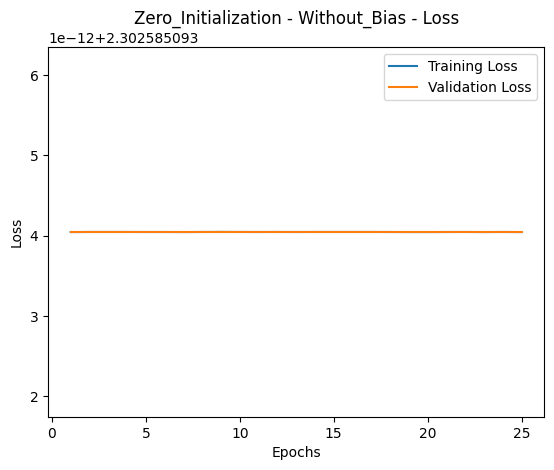

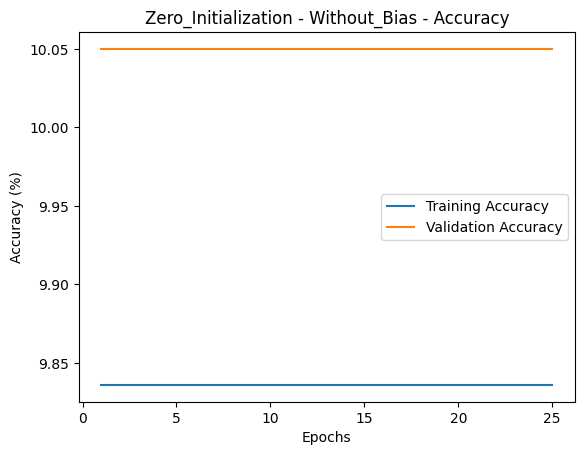

Test Accuracy: 9.80%
Test Error Rate: 90.20%


In [13]:
# 轉換為numpy陣列
X_train = np.array([item[0].numpy().flatten() for item in train_dataset])
y_train = np.array([item[1] for item in train_dataset])
X_val = np.array([item[0].numpy().flatten() for item in val_dataset])
y_val = np.array([item[1] for item in val_dataset])
X_test = np.array([item[0].numpy().flatten() for item in testset])
y_test = np.array([item[1] for item in testset])

# 進行One-Hot編碼
y_train_onehot = one_hot_encode(y_train)
y_val_onehot = one_hot_encode(y_val)
y_test_onehot = one_hot_encode(y_test)

# -----------------------------------------------------------
# 開始訓練
# -----------------------------------------------------------
parameters = initialize_parameters(input_dim, hidden_dim1, hidden_dim2, output_dim, use_bias)
parameters, train_losses, val_losses, train_accuracies, val_accuracies = train_model(
    X_train, y_train_onehot, X_val, y_val_onehot, parameters, learning_rate, num_epochs, batch_size, use_bias)

# -----------------------------------------------------------
# 繪製學習曲線：損失與準確率
# -----------------------------------------------------------
init_type = "Random_Initialization" if weight_random_initialization else "Zero_Initialization"
bias_type = "With_Bias" if use_bias else "Without_Bias"
""
plt.plot(range(1, num_epochs+1), train_losses, label='Training Loss')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title(f'{init_type} - {bias_type} - Loss')
plt.savefig(f'./result/{init_type}_{bias_type}_loss.png')  # 儲存圖片
plt.show()

plt.plot(range(1, num_epochs+1), train_accuracies, label='Training Accuracy')
plt.plot(range(1, num_epochs+1), val_accuracies, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title(f'{init_type} - {bias_type} - Accuracy')
plt.savefig(f'./result/{init_type}_{bias_type}_accuracy.png')  # 儲存圖片
plt.show()

# -----------------------------------------------------------
# 測試模型
# -----------------------------------------------------------
test_model(X_test, y_test_onehot, parameters, use_bias)